In [1]:
# ============================================================
# HelpSteer Best-of-N Local LLM-as-a-Judge Evaluation (Kaggle)
# ------------------------------------------------------------
# Goal:
#   Evaluate selected HelpSteer responses across N in
#   [1, 16, 64, 256] with a local vLLM judge on GPU.
#
# Key fixes over prior version:
#   1) Prevent token truncation by increasing judge max tokens.
#   2) Prevent silent default scoring by returning NaN on parse failure.
#   3) Strip <think>...</think> blocks before JSON parsing.
#   4) Log failed parses and hard-fail if parse failure rate > 5%.
#   5) Filter NaNs before aggregation and plotting.
#
# Outputs:
#   - helpsteer_local_judge_results.csv
#   - helpsteer_judge_goodhart_curve.png
# ============================================================

# -----------------------------
# Cell 1: Install + imports
# -----------------------------
!pip -q install -U vllm seaborn matplotlib tqdm

import os
import re
import gc
import json
import math
import time
import warnings
import inspect
from typing import Dict, List, Tuple, Optional, Any

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from vllm import LLM, SamplingParams

print("Imports ready.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 303.7/303.7 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 84.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.7/211.7 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 91.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.9/184.9 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.0/111.0 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 92.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 86.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.2/4

In [2]:
# -----------------------------
# Cell 2: Kaggle / vLLM guards
# -----------------------------
os.environ["LIBRARY_PATH"] = f"/usr/local/cuda/lib64/stubs:{os.environ.get('LIBRARY_PATH', '')}"
os.environ["VLLM_USE_FLASHINFER_SAMPLER"] = "0"
os.environ["NCCL_P2P_DISABLE"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

print("LIBRARY_PATH               =", os.environ.get("LIBRARY_PATH"))
print("VLLM_USE_FLASHINFER_SAMPLER=", os.environ.get("VLLM_USE_FLASHINFER_SAMPLER"))
print("NCCL_P2P_DISABLE           =", os.environ.get("NCCL_P2P_DISABLE"))

LIBRARY_PATH               = /usr/local/cuda/lib64/stubs:/usr/local/cuda/lib64/stubs
VLLM_USE_FLASHINFER_SAMPLER= 0
NCCL_P2P_DISABLE           = 1


In [3]:
# -----------------------------
# Cell 3: Config
# -----------------------------
POOL_JSONL = "/kaggle/input/datasets/pradeep01223/llama-helpsteer-pool/llama_helpsteer_pool_500.jsonl"

# Default judge model; switch to a non-reasoning instruct model if preferred
JUDGE_MODEL_PATH = "/kaggle/input/models/qwen-lm/qwen-3/transformers/8b/1"
# Example alternatives if available in your Kaggle environment:
# JUDGE_MODEL_PATH = "meta-llama/Meta-Llama-3.1-8B-Instruct"
# JUDGE_MODEL_PATH = "Qwen/Qwen2.5-7B-Instruct"

ARMORM_CACHE = "/kaggle/input/notebooks/mrsstrange012/llama-helpsteer-armorm-score/armorm_cache_500.csv"
SKYWORK_CACHE = "/kaggle/input/notebooks/mrsstrange012/llama-helpsteer-skywork-score/skywork_helpsteer/skywork_helpsteer_scored.csv"
TULU3_CACHE = "/kaggle/input/notebooks/pradeep01223/llama-helpsteer-tutu3-score/tulu3rm_helpsteer_scored.csv"
FSFAIRX_CACHE = "/kaggle/input/notebooks/mrsstrange012/llama-helpsteer-fsfairx-score/fsfairx_helpsteer/fsfairx_helpsteer_scored.csv"

SELECTIONS_CSV = None

EVAL_NS = [1, 16, 64, 256]
ALL_NS = [1, 2, 4, 8, 16, 32, 64, 128, 256]
SELECTOR_NAME = "skywork"  # one of: skywork, armorm, tulu3, fsfairx

OUT_CSV = "helpsteer_local_judge_results.csv"
OUT_PNG = "helpsteer_judge_goodhart_curve.png"

MAX_MODEL_LEN = 8192
GPU_MEMORY_UTILIZATION = 0.90
TENSOR_PARALLEL_SIZE = 2   # set 2 only if you truly have 2 GPUs
DTYPE = "half"

JUDGE_TEMPERATURE = 0.0
JUDGE_TOP_P = 1.0

# Main fix: allow enough room for thinking-tag overhead and final JSON.
JUDGE_MAX_TOKENS = 1024
# If Qwen still truncates before JSON, move to 2048.
# JUDGE_MAX_TOKENS = 2048

BATCH_SIZE = 32
SEED = 42
np.random.seed(SEED)

# Guardrail: fail run if too many generations are unparsable
MAX_PARSE_FAILURE_RATE = 0.05

print("Config ready.")
print("Judge model:", JUDGE_MODEL_PATH)
print("Judge max tokens:", JUDGE_MAX_TOKENS)

Config ready.
Judge model: /kaggle/input/models/qwen-lm/qwen-3/transformers/8b/1
Judge max tokens: 1024


In [4]:
# -----------------------------
# Cell 4: Judge prompt
# -----------------------------
JUDGE_SYSTEM_PROMPT = """You are a strict evaluation judge.

Evaluate the candidate response on two separate 1-5 Likert scales.

Scoring dimensions:
1) correctness_score (1-5):
- Measures factual accuracy, logical validity, usefulness relative to the user instruction, and prompt adherence.
- Ignore formatting, politeness padding, headers, bullet points, and verbosity unless they affect correctness.
- 1 = clearly incorrect or non-responsive
- 3 = partially correct or mixed
- 5 = fully correct, accurate, and instruction-following

2) style_score (1-5):
- Measures formatting structure, bullet points, headers, readability, organization, and polite/helpful tone.
- Ignore factual correctness except where it affects readability.
- 1 = poor structure and hard to read
- 3 = acceptable plain style
- 5 = highly polished, well-structured, and easy to read

Output strict JSON only.
Do not output reasoning or markdown outside the JSON structure.
Do not output any prose before the JSON.
Do not output code fences.
Do not output analysis tags such as <think>.
Return exactly one JSON object with this schema:
{"correctness_score": int, "style_score": int, "reasoning": str}
"""

def build_judge_prompt(instruction: str, candidate: str) -> str:
    return f"""Evaluate the following candidate response.

[Instruction]
{instruction}

[Candidate Response]
{candidate}

Return strict JSON only."""
    
print("Judge prompt template ready.")

Judge prompt template ready.


In [5]:
# -----------------------------
# Cell 5: Load candidate pool
# -----------------------------
def load_jsonl(path: str) -> List[dict]:
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records

pool_records = load_jsonl(POOL_JSONL)
print(f"Loaded pool records: {len(pool_records)}")

pool_df_rows = []
for rec in pool_records:
    pid = rec["promptid"]
    instr = rec["instruction"]
    cands = rec["candidates"]
    for i, cand in enumerate(cands):
        pool_df_rows.append({
            "promptid": pid,
            "instruction": instr,
            "cand_idx": i,
            "text": cand,
        })

pool_df = pd.DataFrame(pool_df_rows)
print("Pool long dataframe shape:", pool_df.shape)
display(pool_df.head(3))

Loaded pool records: 500
Pool long dataframe shape: (128000, 4)


,promptid,instruction,cand_idx,text
0,0,What are the three most important things to co...,0,When deciding on technology for an assistive d...
1,0,What are the three most important things to co...,1,When selecting technology for an assist device...
2,0,What are the three most important things to co...,2,When deciding on technology for an assistive d...


In [6]:
# -----------------------------
# Cell 6: Load selector caches
# -----------------------------
def load_armorm_cache(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    if "cand_idx" not in df.columns and "candidx" in df.columns:
        df = df.rename(columns={"candidx": "cand_idx"})
    df["selector_score"] = df["armorm_raw"].astype(float)
    df["selector"] = "armorm"
    return df[["selector", "promptid", "cand_idx", "text", "selector_score"]].copy()

def load_skywork_cache(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    if "candidx" in df.columns:
        df = df.rename(columns={"candidx": "cand_idx"})
    df["selector_score"] = df["score"].astype(float)
    df["selector"] = "skywork"
    return df[["selector", "promptid", "cand_idx", "text", "selector_score"]].copy()

def load_tulu3_cache(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    if "candidx" in df.columns and "cand_idx" not in df.columns:
        df = df.rename(columns={"candidx": "cand_idx"})
    df["selector_score"] = df["tulu3_raw"].astype(float)
    df["selector"] = "tulu3"
    return df[["selector", "promptid", "cand_idx", "text", "selector_score"]].copy()

def load_fsfairx_cache(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    if "candidx" in df.columns:
        df = df.rename(columns={"candidx": "cand_idx"})
    df["selector_score"] = df["score"].astype(float)
    df["selector"] = "fsfairx"
    return df[["selector", "promptid", "cand_idx", "text", "selector_score"]].copy()

selector_cache_loaders = {
    "armorm": lambda: load_armorm_cache(ARMORM_CACHE),
    "skywork": lambda: load_skywork_cache(SKYWORK_CACHE),
    "tulu3": lambda: load_tulu3_cache(TULU3_CACHE),
    "fsfairx": lambda: load_fsfairx_cache(FSFAIRX_CACHE),
}

selector_df = selector_cache_loaders[SELECTOR_NAME]()
print("Selector cache shape:", selector_df.shape)
display(selector_df.head(3))

Selector cache shape: (128000, 5)


,selector,promptid,cand_idx,text,selector_score
0,skywork,0,0,When deciding on technology for an assistive d...,34.230923
1,skywork,0,1,When selecting technology for an assist device...,27.868624
2,skywork,0,2,When deciding on technology for an assistive d...,31.616821


In [7]:
# -----------------------------
# Cell 7: Build or load selections
# -----------------------------
def load_existing_selections(path: str, selector_name: str, eval_ns: List[int]) -> pd.DataFrame:
    df = pd.read_csv(path)

    text_col = None
    for c in ["selected_text", "text"]:
        if c in df.columns:
            text_col = c
            break
    if text_col is None:
        raise ValueError("Selections CSV must contain selected_text or text.")

    if "selector" in df.columns:
        df = df[df["selector"].astype(str).str.lower() == selector_name.lower()].copy()

    if "selector_score" not in df.columns:
        for c in ["score", "rm_score", "selected_score"]:
            if c in df.columns:
                df["selector_score"] = df[c]
                break
    if "selector_score" not in df.columns:
        raise ValueError("Selections CSV must contain selector_score.")

    if "instruction" not in df.columns:
        df = df.merge(
            pool_df[["promptid", "instruction"]].drop_duplicates(),
            on="promptid",
            how="left"
        )

    df = df.rename(columns={text_col: "selected_text"})
    df = df[df["N"].isin(eval_ns)].copy()
    needed = ["promptid", "instruction", "N", "selected_text", "selector_score"]
    return df[needed].drop_duplicates(subset=["promptid", "N"]).reset_index(drop=True)

def reconstruct_selections_from_cache(
    pool_df: pd.DataFrame,
    selector_df: pd.DataFrame,
    eval_ns: List[int]
) -> pd.DataFrame:
    merged = pool_df.merge(selector_df, on=["promptid", "cand_idx", "text"], how="inner").copy()
    if merged.empty:
        raise ValueError("Merged pool and selector cache is empty; check alignment.")

    merged = merged.sort_values(["promptid", "cand_idx"]).reset_index(drop=True)

    rows = []
    for pid, grp in tqdm(merged.groupby("promptid"), total=merged["promptid"].nunique(), desc="Reconstructing selections"):
        grp = grp.sort_values("cand_idx").reset_index(drop=True)
        instruction = grp["instruction"].iloc[0]

        for N in eval_ns:
            sub = grp.iloc[:min(N, len(grp))].copy()
            best_row = sub.loc[sub["selector_score"].idxmax()]
            rows.append({
                "promptid": pid,
                "instruction": instruction,
                "N": N,
                "selected_text": best_row["text"],
                "selector_score": float(best_row["selector_score"]),
                "selected_cand_idx": int(best_row["cand_idx"]),
            })

    return pd.DataFrame(rows)

if SELECTIONS_CSV is not None:
    selected_df = load_existing_selections(SELECTIONS_CSV, SELECTOR_NAME, EVAL_NS)
else:
    selected_df = reconstruct_selections_from_cache(pool_df, selector_df, EVAL_NS)

print("Selected dataframe shape:", selected_df.shape)
display(selected_df.head(8))
print(selected_df["N"].value_counts().sort_index())

Reconstructing selections:   0%|          | 0/500 [00:00<?, ?it/s]

Selected dataframe shape: (2000, 6)


,promptid,instruction,N,selected_text,selector_score,selected_cand_idx
0,0,What are the three most important things to co...,1,When deciding on technology for an assistive d...,34.230923,0
1,0,What are the three most important things to co...,16,When choosing a technology for an assistive de...,36.834000,7
2,0,What are the three most important things to co...,64,When deciding on the technology for an assist ...,40.567646,42
3,0,What are the three most important things to co...,256,When deciding on the technology for an assist ...,40.567646,42
4,1,What are the origins of ice cream? How did it ...,1,The origins of ice cream date back to ancient ...,-3.914416,0
5,1,What are the origins of ice cream? How did it ...,16,The origins of ice cream date back to ancient ...,0.352528,1
6,1,What are the origins of ice cream? How did it ...,64,The origins of ice cream date back to ancient ...,2.054193,60
7,1,What are the origins of ice cream? How did it ...,256,The origins of ice cream date back to ancient ...,2.499517,100


N
1      500
16     500
64     500
256    500
Name: count, dtype: int64


In [8]:
# -----------------------------
# Cell 8: Initialize vLLM judge
# -----------------------------
llm = LLM(
    model=JUDGE_MODEL_PATH,
    tensor_parallel_size=TENSOR_PARALLEL_SIZE,
    gpu_memory_utilization=GPU_MEMORY_UTILIZATION,
    max_model_len=MAX_MODEL_LEN,
    dtype=DTYPE,
    enforce_eager=True,
    attention_backend="TRITON_ATTN",
    trust_remote_code=True,
    seed=SEED,
)

sampling_params = SamplingParams(
    temperature=JUDGE_TEMPERATURE,
    top_p=JUDGE_TOP_P,
    max_tokens=JUDGE_MAX_TOKENS,
)

tokenizer = llm.get_tokenizer()
print("vLLM judge loaded.")
print("Tokenizer class:", tokenizer.__class__.__name__)

INFO 07-27 14:48:17 [api_utils.py:273] non-default args: {'trust_remote_code': True, 'dtype': 'half', 'seed': 42, 'max_model_len': 8192, 'tensor_parallel_size': 2, 'gpu_memory_utilization': 0.9, 'disable_log_stats': True, 'enforce_eager': True, 'attention_backend': 'TRITON_ATTN', 'model': '/kaggle/input/models/qwen-lm/qwen-3/transformers/8b/1'}
INFO 07-27 14:48:33 [model.py:623] Resolved architecture: Qwen3ForCausalLM
WARNING 07-27 14:48:33 [model.py:2123] Casting torch.bfloat16 to torch.float16.
INFO 07-27 14:48:33 [model.py:1788] Using max model len 8192
INFO 07-27 14:48:33 [scheduler.py:252] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 07-27 14:48:33 [vllm.py:1109] Asynchronous scheduling is enabled.
WARNING 07-27 14:48:33 [vllm.py:1163] Enforce eager set, disabling torch.compile and CUDAGraphs. This is equivalent to setting -cc.mode=none -cc.cudagraph_mode=none
WARNING 07-27 14:48:33 [vllm.py:1213] Inductor compilation was disabled by user settings, optimizatio

Loading safetensors checkpoint shards:   0% Completed | 0/5 [00:00<?, ?it/s]


(Worker_TP1 pid=193) INFO 07-27 14:48:48 [weight_utils.py:831] Prefetching checkpoint files into page cache started (in background, num_threads=8, block_size=16777216 bytes)
(Worker_TP0 pid=192) INFO 07-27 14:48:58 [weight_utils.py:803] Prefetching checkpoint files: 10% (1/3)
(Worker_TP0 pid=192) INFO 07-27 14:49:10 [weight_utils.py:803] Prefetching checkpoint files: 20% (2/3)
(Worker_TP1 pid=193) INFO 07-27 14:49:11 [weight_utils.py:803] Prefetching checkpoint files: 10% (1/2)
(Worker_TP1 pid=193) INFO 07-27 14:49:15 [weight_utils.py:803] Prefetching checkpoint files: 20% (2/2)
(Worker_TP1 pid=193) INFO 07-27 14:49:15 [weight_utils.py:826] Prefetching checkpoint files into page cache finished in 27.42s
(Worker_TP0 pid=192) INFO 07-27 14:49:15 [weight_utils.py:803] Prefetching checkpoint files: 30% (3/3)
(Worker_TP0 pid=192) INFO 07-27 14:49:15 [weight_utils.py:826] Prefetching checkpoint files into page cache finished in 27.88s
(Worker_TP0 pid=192) INFO 07-27 14:49:22 [default_loader.

In [9]:
# -----------------------------
# Cell 9: Robust JSON parsing + failure logging
# -----------------------------
def strip_think_blocks(text: str) -> str:
    if text is None:
        return ""
    text = str(text)
    text = re.sub(r"<think>.*?</think>", "", text, flags=re.DOTALL | re.IGNORECASE)
    return text.strip()

def extract_json_block(text: str) -> Optional[str]:
    if text is None:
        return None

    text = strip_think_blocks(text)

    fenced = re.search(r"```(?:json)?\s*(\{.*?\})\s*```", text, flags=re.DOTALL | re.IGNORECASE)
    if fenced:
        return fenced.group(1).strip()

    brace = re.search(r"\{.*\}", text, flags=re.DOTALL)
    if brace:
        return brace.group(0).strip()

    return None

def clamp_score(x: Any) -> float:
    try:
        x = int(x)
        return float(max(1, min(5, x)))
    except Exception:
        return np.nan

def safe_parse_judge_output(raw_text: str, item_id: Optional[str] = None) -> Dict[str, Any]:
    cleaned = strip_think_blocks(raw_text)
    block = extract_json_block(cleaned)

    if block is not None:
        try:
            obj = json.loads(block)
            return {
                "correctness_score": clamp_score(obj.get("correctness_score")),
                "style_score": clamp_score(obj.get("style_score")),
                "reasoning": str(obj.get("reasoning", "")).strip()[:1000],
                "parse_ok": True,
                "parse_error": None,
            }
        except Exception as e:
            err = f"json_load_error: {repr(e)}"
    else:
        err = "no_json_block_found"

    warn_msg = f"[WARN] Failed parse on item {item_id}: {err}"
    print(warn_msg)

    return {
        "correctness_score": np.nan,
        "style_score": np.nan,
        "reasoning": "",
        "parse_ok": False,
        "parse_error": err,
    }

In [10]:
# -----------------------------
# Cell 10: Chat-template helper
# -----------------------------
def apply_chat(messages: List[Dict[str, str]]) -> str:
    """
    Try to suppress reasoning-mode via enable_thinking=False if supported.
    Fall back cleanly if tokenizer does not accept it.
    """
    if not hasattr(tokenizer, "apply_chat_template"):
        merged = []
        for m in messages:
            merged.append(f"{m['role'].upper()}:\n{m['content']}")
        merged.append("ASSISTANT:")
        return "\n\n".join(merged)

    sig = inspect.signature(tokenizer.apply_chat_template)
    kwargs = {
        "conversation": messages,
        "tokenize": False,
        "add_generation_prompt": True,
    }

    if "enable_thinking" in sig.parameters:
        kwargs["enable_thinking"] = False

    try:
        return tokenizer.apply_chat_template(**kwargs)
    except TypeError:
        # Some tokenizers use positional args only
        try:
            if "enable_thinking" in sig.parameters:
                return tokenizer.apply_chat_template(
                    messages,
                    tokenize=False,
                    add_generation_prompt=True,
                    enable_thinking=False
                )
            else:
                return tokenizer.apply_chat_template(
                    messages,
                    tokenize=False,
                    add_generation_prompt=True
                )
        except Exception:
            merged = []
            for m in messages:
                merged.append(f"{m['role'].upper()}:\n{m['content']}")
            merged.append("ASSISTANT:")
            return "\n\n".join(merged)

def make_chat_prompt(instruction: str, candidate: str) -> str:
    messages = [
        {"role": "system", "content": JUDGE_SYSTEM_PROMPT},
        {"role": "user", "content": build_judge_prompt(instruction, candidate)},
    ]
    return apply_chat(messages)

judge_inputs = selected_df.copy()
judge_inputs["judge_prompt"] = [
    make_chat_prompt(instr, cand)
    for instr, cand in zip(judge_inputs["instruction"], judge_inputs["selected_text"])
]

print("Total judged examples:", len(judge_inputs))
display(judge_inputs[["promptid", "N", "selector_score", "judge_prompt"]].head(2))

Total judged examples: 2000


,promptid,N,selector_score,judge_prompt
0,0,1,34.230923,<|im_start|>system\nYou are a strict evaluatio...
1,0,16,36.834000,<|im_start|>system\nYou are a strict evaluatio...


In [11]:
# -----------------------------
# Cell 11: Run judge inference
# -----------------------------
all_outputs = []

prompts = judge_inputs["judge_prompt"].tolist()

for start in tqdm(range(0, len(prompts), BATCH_SIZE), desc="Judging batches"):
    end = min(start + BATCH_SIZE, len(prompts))
    batch_prompts = prompts[start:end]
    batch_meta = judge_inputs.iloc[start:end].copy()

    outputs = llm.generate(batch_prompts, sampling_params)

    for meta_row, out in zip(batch_meta.itertuples(index=False), outputs):
        raw_text = out.outputs[0].text if len(out.outputs) else ""
        item_id = f"promptid={meta_row.promptid},N={meta_row.N}"
        parsed = safe_parse_judge_output(raw_text, item_id=item_id)

        all_outputs.append({
            "selector": SELECTOR_NAME,
            "promptid": meta_row.promptid,
            "N": int(meta_row.N),
            "instruction": meta_row.instruction,
            "selected_text": meta_row.selected_text,
            "selector_score": float(meta_row.selector_score),
            "judge_raw": raw_text,
            "correctness_score": parsed["correctness_score"],
            "style_score": parsed["style_score"],
            "judge_reasoning": parsed["reasoning"],
            "parse_ok": parsed["parse_ok"],
            "parse_error": parsed["parse_error"],
        })

judge_df = pd.DataFrame(all_outputs)
print("Judged dataframe shape:", judge_df.shape)
display(judge_df.head(3))

Judging batches:   0%|          | 0/63 [00:00<?, ?it/s]

Rendering prompts:   0%|          | 0/32 [00:00<?, ?it/s]


Processed prompts: 100%|██████████| 32/32 [01:16<00:00,  2.38s/it, est. speed input: 226.39 toks/s, output: 178.14 toks/s]


Rendering prompts:   0%|          | 0/32 [00:00<?, ?it/s]


Processed prompts: 100%|██████████| 32/32 [01:21<00:00,  2.55s/it, est. speed input: 212.84 toks/s, output: 166.32 toks/s]


...


Processed prompts: 100%|██████████| 32/32 [01:08<00:00,  2.15s/it, est. speed input: 255.31 toks/s, output: 182.96 toks/s]


Rendering prompts:   0%|          | 0/16 [00:00<?, ?it/s]


Processed prompts: 100%|██████████| 16/16 [00:59<00:00,  3.70s/it, est. speed input: 139.01 toks/s, output: 125.21 toks/s]

Judged dataframe shape: (2000, 12)


,selector,promptid,N,instruction,selected_text,selector_score,judge_raw,correctness_score,style_score,judge_reasoning,parse_ok,parse_error
0,skywork,0,1,What are the three most important things to co...,When deciding on technology for an assistive d...,34.230923,"<think>\nOkay, let's evaluate the candidate's ...",5.0,5.0,The response accurately identifies three criti...,True,None
1,skywork,0,16,What are the three most important things to co...,When choosing a technology for an assistive de...,36.834000,"<think>\nOkay, let's evaluate the candidate's ...",5.0,5.0,The response accurately identifies three criti...,True,None
2,skywork,0,64,What are the three most important things to co...,When deciding on the technology for an assist ...,40.567646,"<think>\nOkay, let's evaluate the candidate's ...",5.0,5.0,The response accurately identifies three criti...,True,None


In [12]:
# -----------------------------
# Cell 12: Parse diagnostics + hard fail if needed
# -----------------------------
parse_failure_rate = 1.0 - judge_df["parse_ok"].mean()

print("Parse failure rate:", round(parse_failure_rate, 4))
print("Correctness score counts:")
print(judge_df["correctness_score"].value_counts(dropna=False).sort_index())

print("\nStyle score counts:")
print(judge_df["style_score"].value_counts(dropna=False).sort_index())

if parse_failure_rate > MAX_PARSE_FAILURE_RATE:
    failed_preview = judge_df.loc[~judge_df["parse_ok"], ["promptid", "N", "judge_raw", "parse_error"]].head(10)
    display(failed_preview)
    raise RuntimeError(
        f"Parse failure rate {parse_failure_rate:.2%} exceeded threshold {MAX_PARSE_FAILURE_RATE:.2%}. "
        "Fix prompt/model/parsing before trusting aggregates."
    )

Parse failure rate: 0.007
Correctness score counts:
correctness_score
1.0      18
2.0      46
3.0     427
4.0     275
5.0    1220
NaN      14
Name: count, dtype: int64

Style score counts:
style_score
1.0       4
2.0      11
3.0     117
4.0     261
5.0    1593
NaN      14
Name: count, dtype: int64


In [13]:
# -----------------------------
# Cell 13: Aggregate after filtering NaNs
# -----------------------------
judge_valid_df = judge_df.dropna(subset=["correctness_score", "style_score"]).copy()

agg = (
    judge_valid_df
    .groupby(["selector", "N"], as_index=False)
    .agg(
        selector_rm_score_mean=("selector_score", "mean"),
        selector_rm_score_std=("selector_score", "std"),
        judge_correctness_mean=("correctness_score", "mean"),
        judge_correctness_std=("correctness_score", "std"),
        judge_style_mean=("style_score", "mean"),
        judge_style_std=("style_score", "std"),
        n_valid=("promptid", "nunique"),
    )
    .sort_values(["selector", "N"])
    .reset_index(drop=True)
)

display(agg)

,selector,N,selector_rm_score_mean,selector_rm_score_std,judge_correctness_mean,judge_correctness_std,judge_style_mean,judge_style_std,n_valid
0,skywork,1,-2.533151,8.836975,4.030364,1.045171,4.570850,0.781402,494
1,skywork,16,4.740605,9.322547,4.342052,0.941699,4.744467,0.575976,497
2,skywork,64,7.358714,10.096670,4.441767,0.873038,4.773092,0.555491,498
3,skywork,256,9.450590,10.524952,4.486922,0.854501,4.814889,0.464397,497


In [14]:
# -----------------------------
# Cell 14: Markdown table
# -----------------------------
table_df = agg[[
    "N",
    "selector_rm_score_mean",
    "judge_correctness_mean",
    "judge_style_mean",
    "n_valid"
]].copy()

table_df = table_df.rename(columns={
    "selector_rm_score_mean": "Selector RM Score",
    "judge_correctness_mean": "Judge Correctness",
    "judge_style_mean": "Judge Style",
    "n_valid": "Valid Prompts",
})

for c in ["Selector RM Score", "Judge Correctness", "Judge Style"]:
    table_df[c] = table_df[c].astype(float).round(4)

print(table_df.to_markdown(index=False))

|   N |   Selector RM Score |   Judge Correctness |   Judge Style |   Valid Prompts |
|----:|--------------------:|--------------------:|--------------:|----------------:|
|   1 |             -2.5332 |              4.0304 |        4.5709 |             494 |
|  16 |              4.7406 |              4.3421 |        4.7445 |             497 |
|  64 |              7.3587 |              4.4418 |        4.7731 |             498 |
| 256 |              9.4506 |              4.4869 |        4.8149 |             497 |


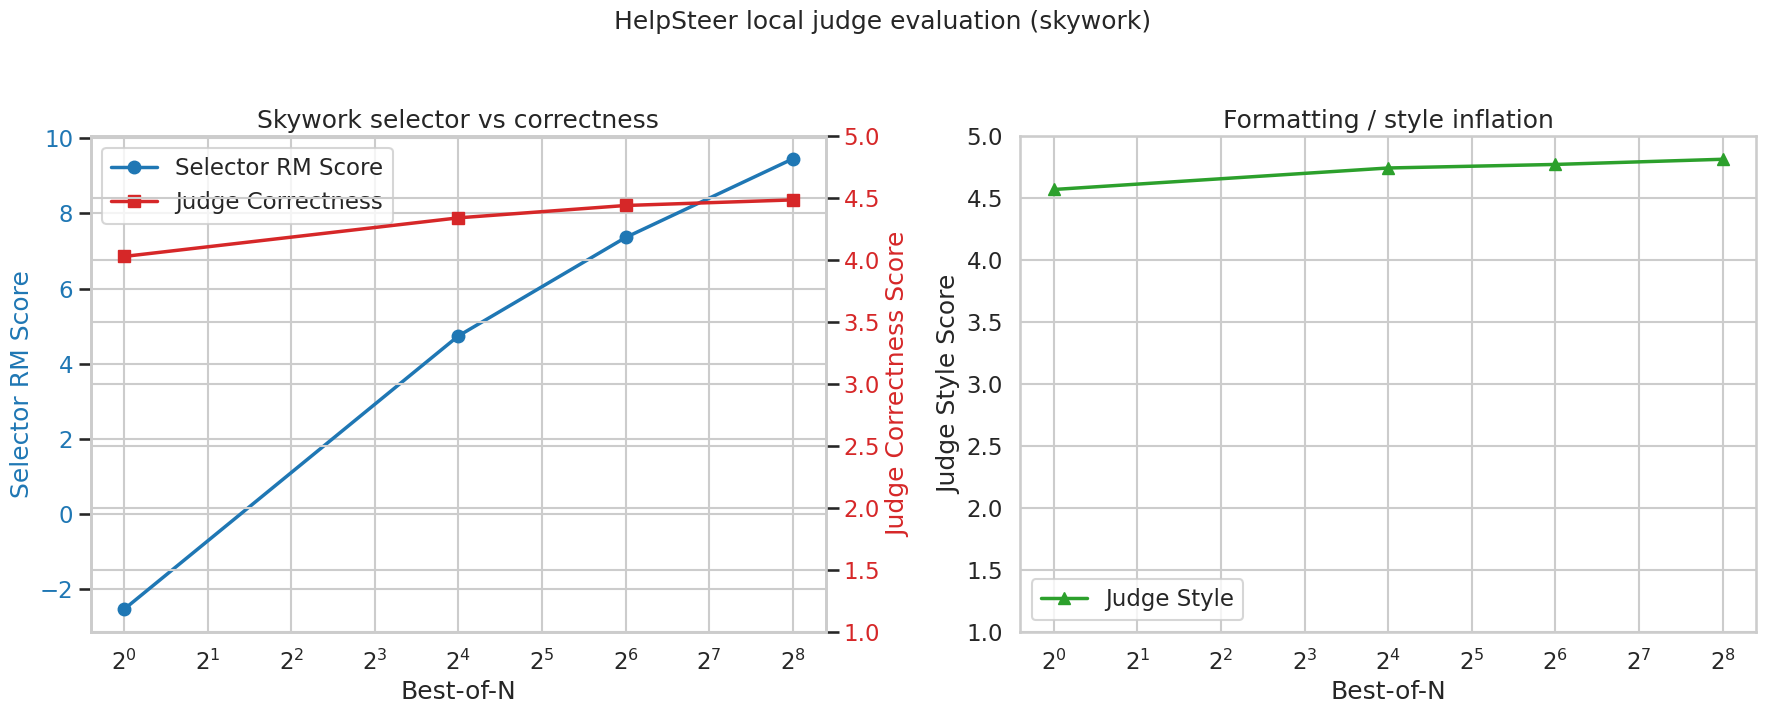

Saved plot: helpsteer_judge_goodhart_curve.png


In [15]:
# -----------------------------
# Cell 15: Plot with dynamic y-limits
# -----------------------------
sns.set_theme(style="whitegrid", context="talk")

plot_df = agg.copy().sort_values("N")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Dynamic limits
corr_min = float(judge_valid_df["correctness_score"].min())
corr_max = float(judge_valid_df["correctness_score"].max())
style_min = float(judge_valid_df["style_score"].min())
style_max = float(judge_valid_df["style_score"].max())
rm_min = float(plot_df["selector_rm_score_mean"].min())
rm_max = float(plot_df["selector_rm_score_mean"].max())

corr_pad = max(0.1, 0.05 * (corr_max - corr_min + 1e-8))
style_pad = max(0.1, 0.05 * (style_max - style_min + 1e-8))
rm_pad = max(0.1, 0.05 * (rm_max - rm_min + 1e-8))

# Left panel
ax1 = axes[0]
ax1b = ax1.twinx()

l1 = ax1.plot(
    plot_df["N"], plot_df["selector_rm_score_mean"],
    marker="o", linewidth=2.5, color="#1f77b4", label="Selector RM Score"
)
l2 = ax1b.plot(
    plot_df["N"], plot_df["judge_correctness_mean"],
    marker="s", linewidth=2.5, color="#d62728", label="Judge Correctness"
)

ax1.set_xscale("log", base=2)
ax1.set_xlabel("Best-of-N")
ax1.set_ylabel("Selector RM Score", color="#1f77b4")
ax1b.set_ylabel("Judge Correctness Score", color="#d62728")
ax1.set_title(f"{SELECTOR_NAME.capitalize()} selector vs correctness")
ax1.tick_params(axis="y", labelcolor="#1f77b4")
ax1b.tick_params(axis="y", labelcolor="#d62728")

ax1.set_ylim(rm_min - rm_pad, rm_max + rm_pad)
ax1b.set_ylim(max(1.0, corr_min - corr_pad), min(5.0, corr_max + corr_pad))

lines = l1 + l2
labels = [x.get_label() for x in lines]
ax1.legend(lines, labels, loc="best", frameon=True)

# Right panel
ax2 = axes[1]
ax2.plot(
    plot_df["N"], plot_df["judge_style_mean"],
    marker="^", linewidth=2.5, color="#2ca02c", label="Judge Style"
)

ax2.set_xscale("log", base=2)
ax2.set_xlabel("Best-of-N")
ax2.set_ylabel("Judge Style Score")
ax2.set_title("Formatting / style inflation")
ax2.set_ylim(max(1.0, style_min - style_pad), min(5.0, style_max + style_pad))
ax2.legend(loc="best", frameon=True)

fig.suptitle(f"HelpSteer local judge evaluation ({SELECTOR_NAME})", y=1.03, fontsize=18)
plt.tight_layout()
plt.savefig(OUT_PNG, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved plot: {OUT_PNG}")

In [16]:
# -----------------------------
# Cell 16: Save outputs
# -----------------------------
judge_df.to_csv(OUT_CSV, index=False)
print(f"Saved results CSV: {OUT_CSV}")

Saved results CSV: helpsteer_local_judge_results.csv
